In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda x: "%.4f" % x)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

heart = pd.read_csv("../../data/health_risk/heart.csv")
diabetes = pd.read_csv("../../data/health_risk/diabetes.csv")

print("HEART DISEASE DATASET")
print("Shape          :", heart.shape)
print("Target (1=disease):", heart["target"].value_counts().to_dict())
print("Disease rate   :", round(heart["target"].mean() * 100, 2), "%")
print()
print("DIABETES DATASET")
print("Shape          :", diabetes.shape)
print("Target (1=diabetes):", diabetes["Outcome"].value_counts().to_dict())
print("Diabetes rate  :", round(diabetes["Outcome"].mean() * 100, 2), "%")
print()
print("Heart columns  :", list(heart.columns))
print("Diabetes columns:", list(diabetes.columns))

HEART DISEASE DATASET
Shape          : (1025, 14)
Target (1=disease): {1: 526, 0: 499}
Disease rate   : 51.32 %

DIABETES DATASET
Shape          : (768, 9)
Target (1=diabetes): {0: 500, 1: 268}
Diabetes rate  : 34.9 %

Heart columns  : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Diabetes columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [2]:
# Heart Disease Data Quality
print("HEART DISEASE DATA QUALITY")
print()

print("Missing values:")
print(heart.isnull().sum())
print()

print("Data types:")
print(heart.dtypes)
print()

print("Basic statistics:")
print(heart.describe().round(3))
print()

print("Feature descriptions:")
features_info = {
    "age": "Age in years",
    "sex": "Sex (1=male, 0=female)",
    "cp": "Chest pain type (0-3)",
    "trestbps": "Resting blood pressure (mmHg)",
    "chol": "Serum cholesterol (mg/dl)",
    "fbs": "Fasting blood sugar > 120 mg/dl (1=true)",
    "restecg": "Resting ECG results (0-2)",
    "thalach": "Maximum heart rate achieved",
    "exang": "Exercise induced angina (1=yes)",
    "oldpeak": "ST depression induced by exercise",
    "slope": "Slope of peak exercise ST segment",
    "ca": "Number of major vessels (0-3)",
    "thal": "Thalassemia (1=normal, 2=fixed defect, 3=reversible defect)",
    "target": "Heart disease (1=yes, 0=no)"
}
for feat, desc in features_info.items():
    print(f"  {feat:<12}: {desc}")

HEART DISEASE DATA QUALITY

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Basic statistics:
            age       sex        cp  trestbps      chol       fbs   restecg  \
count 1025.0000 1025.0000 1025.0000 1025.0000 1025.0000 1025.0000 1025.0000   
mean    54.4340    0.6960    0.9420  131.6120  246.0000    0.1490    0.5300   
std      9.0720    0.4600    1.0300   17.5170   51.5930    0.3570    0.5280   
min     29.0000    0.0000    0.0000   94.0000  126.0000    0.0000    0.0000   
25%     48.0000    0.0000 

HEART DISEASE DISTRIBUTION ANALYSIS

With disease    : 526 (51.3%)
Without disease : 499 (48.7%)

  age         : disease mean=52.41  no disease mean=56.57  diff=4.16
  trestbps    : disease mean=129.25  no disease mean=134.11  diff=4.86
  chol        : disease mean=240.98  no disease mean=251.29  diff=10.31
  thalach     : disease mean=158.59  no disease mean=139.13  diff=19.46
  oldpeak     : disease mean=0.57  no disease mean=1.60  diff=1.03


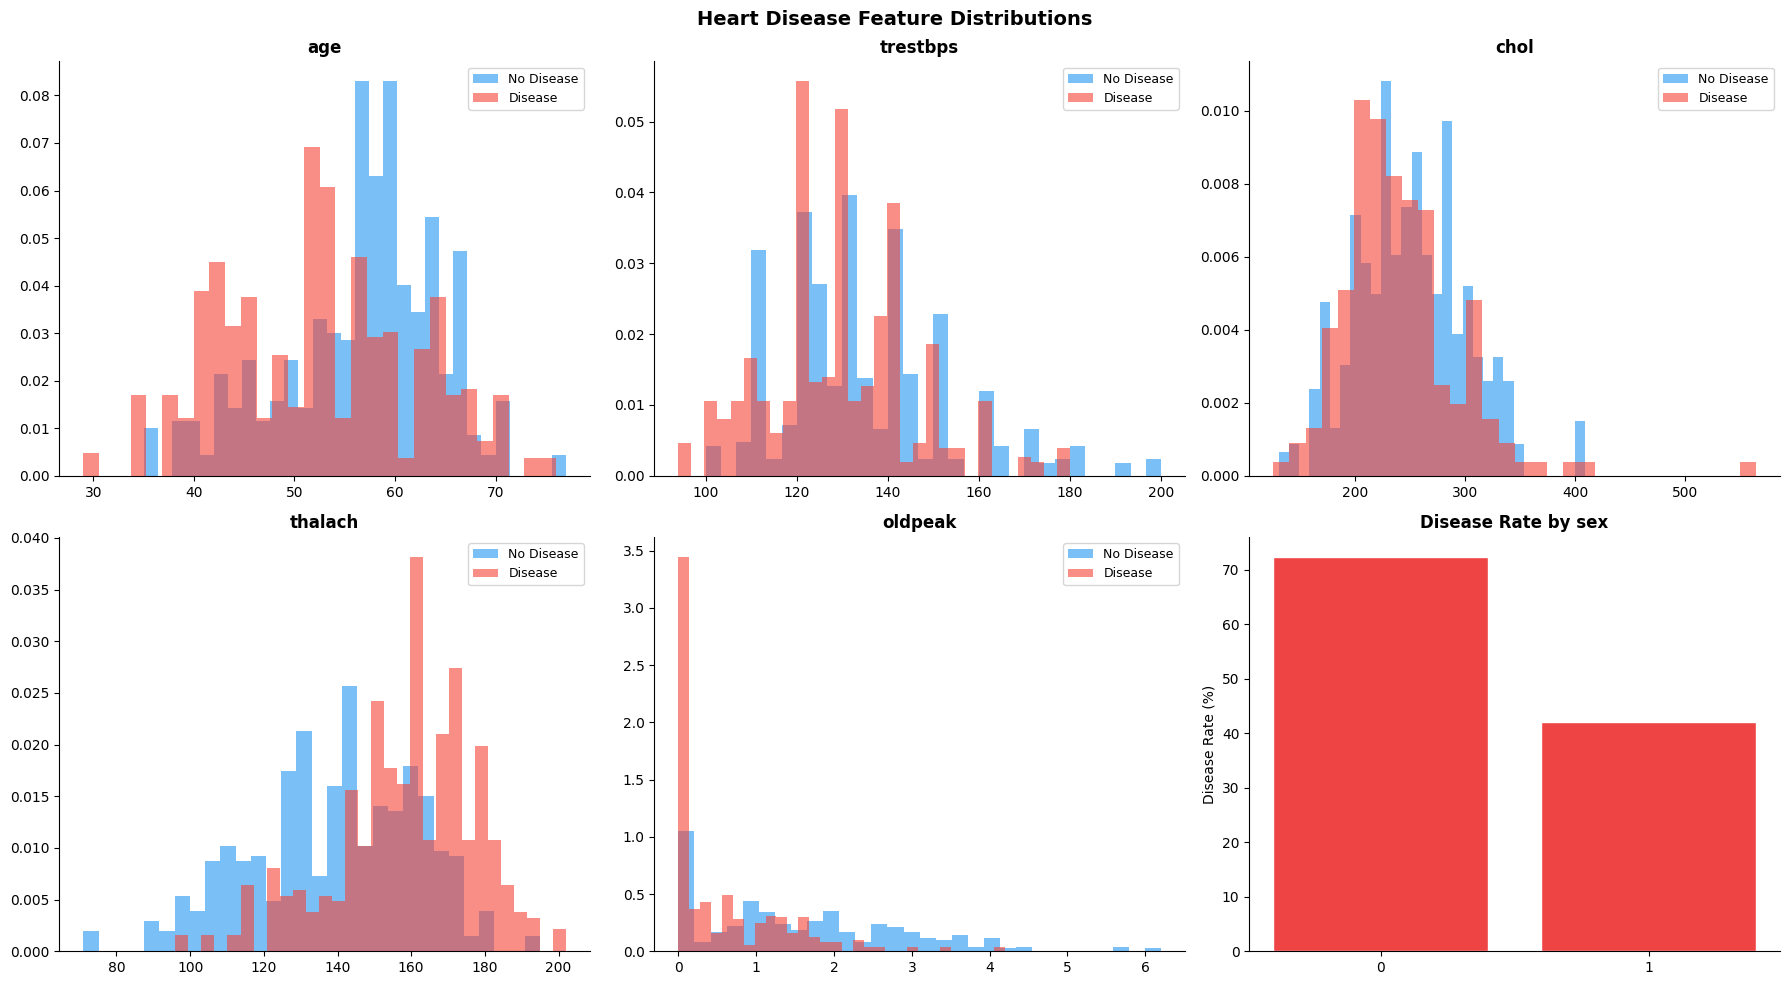


Disease rate by chest pain type:
cp
0   24.5500
1   80.2400
2   77.1100
3   66.2300
Name: target, dtype: float64

Disease rate by sex:
sex
0   72.4400
1   42.0800
Name: target, dtype: float64


In [3]:
# Heart Disease Distribution Analysis
print("HEART DISEASE DISTRIBUTION ANALYSIS")
print()

disease = heart[heart["target"] == 1]
no_disease = heart[heart["target"] == 0]

print(f"With disease    : {len(disease)} ({len(disease)/len(heart)*100:.1f}%)")
print(f"Without disease : {len(no_disease)} ({len(no_disease)/len(heart)*100:.1f}%)")
print()

numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
for col in numeric_cols:
    d_mean = disease[col].mean()
    nd_mean = no_disease[col].mean()
    print(f"  {col:<12}: disease mean={d_mean:.2f}  no disease mean={nd_mean:.2f}  diff={abs(d_mean-nd_mean):.2f}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(no_disease[col], bins=30, color="#2196F3", alpha=0.6, label="No Disease", density=True)
    axes[i].hist(disease[col], bins=30, color="#F44336", alpha=0.6, label="Disease", density=True)
    axes[i].set_title(col, fontweight="bold")
    axes[i].legend(fontsize=9)

cat_cols = ["sex", "cp", "fbs", "exang"]
disease_rates = {col: heart.groupby(col)["target"].mean() * 100 for col in cat_cols}
for j, (col, rates) in enumerate(disease_rates.items()):
    if j == 0:
        ax = axes[5]
        ax.bar(rates.index.astype(str), rates.values, color="#ef4444", edgecolor="white")
        ax.set_title(f"Disease Rate by {col}", fontweight="bold")
        ax.set_ylabel("Disease Rate (%)")

plt.suptitle("Heart Disease Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/health_risk/heart_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print("Disease rate by chest pain type:")
print(heart.groupby("cp")["target"].mean().round(4) * 100)
print()
print("Disease rate by sex:")
print(heart.groupby("sex")["target"].mean().round(4) * 100)

DIABETES DISTRIBUTION ANALYSIS

Diabetic     : 268 (34.9%)
Non-diabetic : 500 (65.1%)

Feature analysis:
  Pregnancies                 : diabetic=4.87  non-diabetic=3.30  (47.5% diff)
  Glucose                     : diabetic=141.26  non-diabetic=109.98  (28.4% diff)
  BloodPressure               : diabetic=70.82  non-diabetic=68.18  (3.9% diff)
  SkinThickness               : diabetic=22.16  non-diabetic=19.66  (12.7% diff)
  Insulin                     : diabetic=100.34  non-diabetic=68.79  (45.9% diff)
  BMI                         : diabetic=35.14  non-diabetic=30.30  (16.0% diff)
  DiabetesPedigreeFunction    : diabetic=0.55  non-diabetic=0.43  (28.1% diff)
  Age                         : diabetic=37.07  non-diabetic=31.19  (18.8% diff)

Zero values (likely missing data):
  Glucose                     : 5 zeros (0.7%)
  BloodPressure               : 35 zeros (4.6%)
  SkinThickness               : 227 zeros (29.6%)
  Insulin                     : 374 zeros (48.7%)
  BMI             

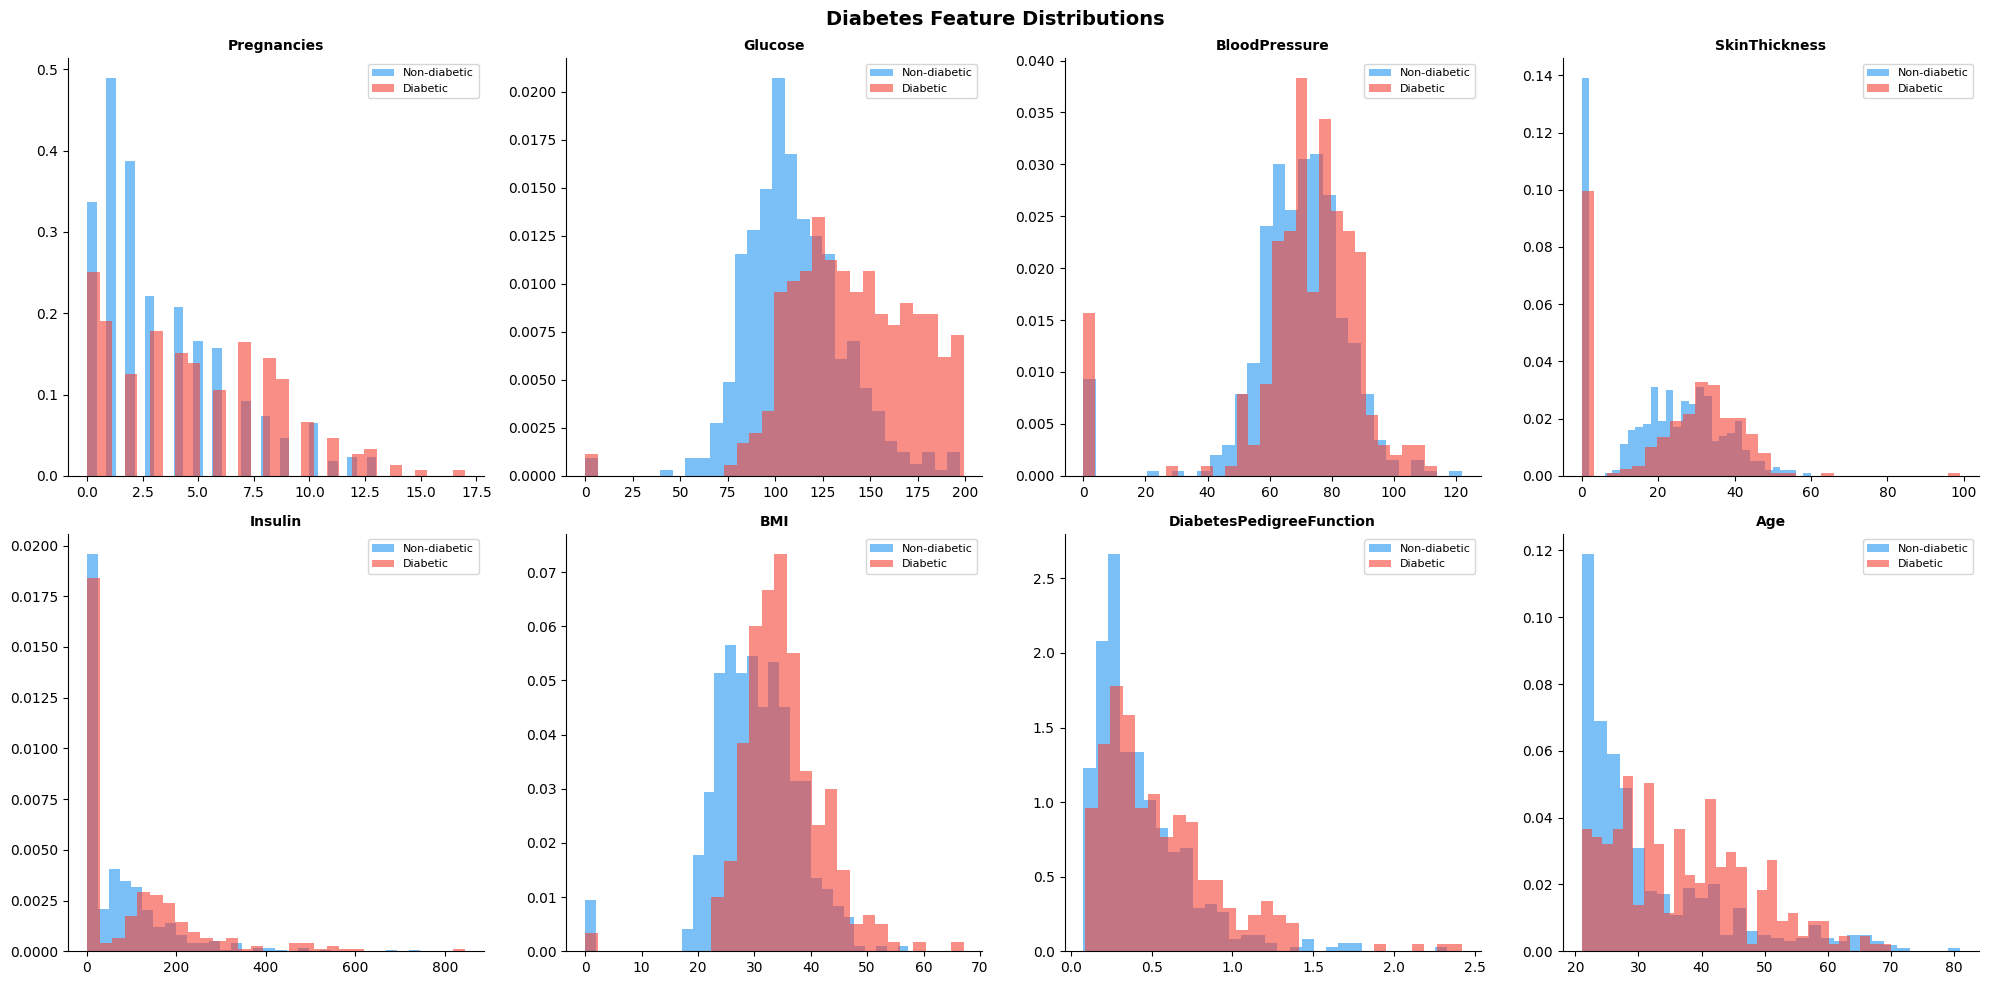

In [4]:
#  Diabetes Distribution Analysis
print("DIABETES DISTRIBUTION ANALYSIS")
print()

diabetic = diabetes[diabetes["Outcome"] == 1]
non_diabetic = diabetes[diabetes["Outcome"] == 0]

print(f"Diabetic     : {len(diabetic)} ({len(diabetic)/len(diabetes)*100:.1f}%)")
print(f"Non-diabetic : {len(non_diabetic)} ({len(non_diabetic)/len(diabetes)*100:.1f}%)")
print()

feature_info = {
    "Pregnancies": "Number of pregnancies",
    "Glucose": "Plasma glucose concentration",
    "BloodPressure": "Diastolic blood pressure (mmHg)",
    "SkinThickness": "Triceps skin fold thickness (mm)",
    "Insulin": "2-Hour serum insulin (mu U/ml)",
    "BMI": "Body mass index",
    "DiabetesPedigreeFunction": "Diabetes pedigree function",
    "Age": "Age in years"
}

print("Feature analysis:")
for feat, desc in feature_info.items():
    d_mean = diabetic[feat].mean()
    nd_mean = non_diabetic[feat].mean()
    diff_pct = abs(d_mean - nd_mean) / (nd_mean + 1e-10) * 100
    print(f"  {feat:<28}: diabetic={d_mean:.2f}  non-diabetic={nd_mean:.2f}  ({diff_pct:.1f}% diff)")

print()
print("Zero values (likely missing data):")
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_cols:
    zeros = (diabetes[col] == 0).sum()
    zero_pct = zeros / len(diabetes) * 100
    print(f"  {col:<28}: {zeros} zeros ({zero_pct:.1f}%)")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(feature_info.keys()):
    axes[i].hist(non_diabetic[col], bins=30, color="#2196F3", alpha=0.6, label="Non-diabetic", density=True)
    axes[i].hist(diabetic[col], bins=30, color="#F44336", alpha=0.6, label="Diabetic", density=True)
    axes[i].set_title(col, fontweight="bold", fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle("Diabetes Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/health_risk/diabetes_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

CORRELATION ANALYSIS

Heart Disease — Top correlations with target:
oldpeak   0.4384
exang     0.4380
cp        0.4349
thalach   0.4229
ca        0.3821
slope     0.3455
thal      0.3378
sex       0.2795
Name: target, dtype: float64

Diabetes — Top correlations with Outcome:
Glucose                    0.4666
BMI                        0.2927
Age                        0.2384
Pregnancies                0.2219
DiabetesPedigreeFunction   0.1738
Insulin                    0.1305
SkinThickness              0.0748
BloodPressure              0.0651
Name: Outcome, dtype: float64


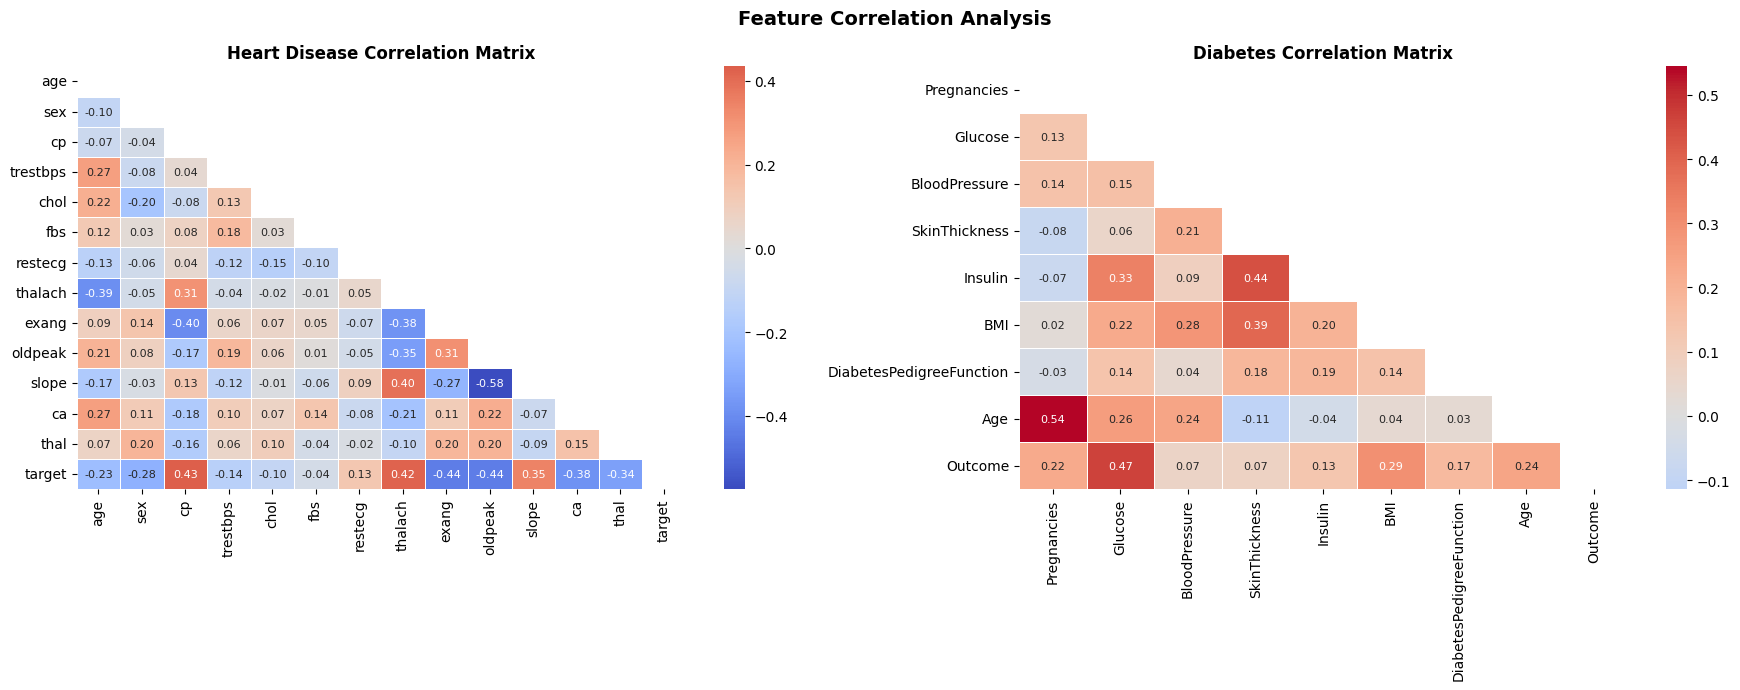

In [5]:
# Correlation Analysis
print("CORRELATION ANALYSIS")
print()

print("Heart Disease — Top correlations with target:")
heart_corr = heart.corr()["target"].abs().sort_values(ascending=False)
print(heart_corr.drop("target").head(8).round(4))

print()
print("Diabetes — Top correlations with Outcome:")
diabetes_corr = diabetes.corr()["Outcome"].abs().sort_values(ascending=False)
print(diabetes_corr.drop("Outcome").head(8).round(4))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask_h = np.triu(np.ones_like(heart.corr(), dtype=bool))
sns.heatmap(heart.corr(), mask=mask_h, ax=axes[0], cmap="coolwarm",
            center=0, annot=True, fmt=".2f", linewidths=0.5, annot_kws={"size": 8})
axes[0].set_title("Heart Disease Correlation Matrix", fontweight="bold")

mask_d = np.triu(np.ones_like(diabetes.corr(), dtype=bool))
sns.heatmap(diabetes.corr(), mask=mask_d, ax=axes[1], cmap="coolwarm",
            center=0, annot=True, fmt=".2f", linewidths=0.5, annot_kws={"size": 8})
axes[1].set_title("Diabetes Correlation Matrix", fontweight="bold")

plt.suptitle("Feature Correlation Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/health_risk/correlations.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Key Findings and Save
print("KEY FINDINGS")
print()

print("HEART DISEASE:")
print(f"  Dataset size      : {len(heart)} patients")
print(f"  Disease rate      : {heart['target'].mean()*100:.1f}% (balanced dataset)")
print(f"  Strongest signal  : thalach (max heart rate) correlation={abs(heart.corr()['target']['thalach']):.4f}")
print(f"  Second signal     : cp (chest pain type) correlation={abs(heart.corr()['target']['cp']):.4f}")
print(f"  Males vs females  : Males {heart[heart['sex']==1]['target'].mean()*100:.1f}% vs Females {heart[heart['sex']==0]['target'].mean()*100:.1f}% disease rate")
print()
print("DIABETES:")
print(f"  Dataset size      : {len(diabetes)} patients")
print(f"  Diabetes rate     : {diabetes['Outcome'].mean()*100:.1f}% (imbalanced)")
print(f"  Strongest signal  : Glucose correlation={abs(diabetes.corr()['Outcome']['Glucose']):.4f}")
print(f"  Second signal     : BMI correlation={abs(diabetes.corr()['Outcome']['BMI']):.4f}")
print(f"  Data quality issue: Glucose, BMI, BP have zero values that must be treated as missing")
print()
print("COMBINED STRATEGY:")
print("  We will train separate models for each disease")
print("  Then combine predictions into a unified health risk score")
print("  This mirrors how Google Health and DeepMind approach multi-disease prediction")

import os
os.makedirs("../../data/health_risk", exist_ok=True)
heart.to_csv("../../data/health_risk/heart_cleaned.csv", index=False)

diabetes_clean = diabetes.copy()
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_cols:
    diabetes_clean[col] = diabetes_clean[col].replace(0, np.nan)
    diabetes_clean[col] = diabetes_clean[col].fillna(diabetes_clean[col].median())

diabetes_clean.to_csv("../../data/health_risk/diabetes_cleaned.csv", index=False)
print()
print("Cleaned data saved.")
print("Notebook 1 complete.")

KEY FINDINGS

HEART DISEASE:
  Dataset size      : 1025 patients
  Disease rate      : 51.3% (balanced dataset)
  Strongest signal  : thalach (max heart rate) correlation=0.4229
  Second signal     : cp (chest pain type) correlation=0.4349
  Males vs females  : Males 42.1% vs Females 72.4% disease rate

DIABETES:
  Dataset size      : 768 patients
  Diabetes rate     : 34.9% (imbalanced)
  Strongest signal  : Glucose correlation=0.4666
  Second signal     : BMI correlation=0.2927
  Data quality issue: Glucose, BMI, BP have zero values that must be treated as missing

COMBINED STRATEGY:
  We will train separate models for each disease
  Then combine predictions into a unified health risk score
  This mirrors how Google Health and DeepMind approach multi-disease prediction

Cleaned data saved.
Notebook 1 complete.
